In [2]:
# ==========================================
# STANDARD IMPORTS & SETUP
# ==========================================
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms, models
import matplotlib.pyplot as plt
import numpy as np
import time

# Device configuration (Utilize GPU if available)
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

# Set random seeds for reproducibility
torch.manual_seed(42)
if device == "cuda":
    torch.cuda.manual_seed_all(42)



Using device: cpu


In [3]:
# ==========================================
# DATA PREPROCESSING & LOADERS
# ==========================================
imagenet_mean = [0.485, 0.456, 0.406]
imagenet_std  = [0.229, 0.224, 0.225]

train_tf = transforms.Compose([
    transforms.Resize(232),
    transforms.RandomCrop(224),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(imagenet_mean, imagenet_std),
])

val_tf = transforms.Compose([
    transforms.Resize(232),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(imagenet_mean, imagenet_std),
])

# Load Flowers-102 dataset splits (Automatically downloads)
print("Downloading and loading datasets...")
train_dataset = datasets.Flowers102(root=".", split="train", download=True, transform=train_tf)
val_dataset   = datasets.Flowers102(root=".", split="val", download=True, transform=val_tf)
test_dataset  = datasets.Flowers102(root=".", split="test", download=True, transform=val_tf)

# DataLoaders configuration
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=2)
val_loader   = DataLoader(val_dataset, batch_size=32, shuffle=False, num_workers=2)
test_loader  = DataLoader(test_dataset, batch_size=32, shuffle=False, num_workers=2)

print(f"Dataset Sizes -> Train: {len(train_dataset)}, Val: {len(val_dataset)}, Test: {len(test_dataset)}")

100%|██████████| 345M/345M [02:30<00:00, 2.29MB/s] 
100%|██████████| 502/502 [00:00<00:00, 203kB/s]
100%|██████████| 15.0k/15.0k [00:00<00:00, 7.46MB/s]


Dataset Sizes -> Train: 1020, Val: 1020, Test: 6149


In [13]:
def train_model(model, criterion, optimizer, scheduler, num_epochs, model_name="Model"):
    history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}
    best_val_acc = 0.0
    start_time = time.time()
    
    total_batches = len(train_loader) 
    
    for epoch in range(num_epochs):
        # Training Phase
        model.train()
        running_loss = 0.0
        running_corrects = 0
        
        print(f"\n--- {model_name} | Epoch {epoch+1}/{num_epochs} Training began ---")
        
       
        for batch_idx, (inputs, labels) in enumerate(train_loader):
            inputs, labels = inputs.to(device), labels.to(device)
            
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            
            _, preds = torch.max(outputs, 1)
            running_loss += loss.item() * inputs.size(0)
            running_corrects += torch.sum(preds == labels.data)
            
           
            if (batch_idx + 1) % 5 == 0 or (batch_idx + 1) == total_batches:
                print(f"Batch {batch_idx + 1}/{total_batches} processing... Loss: {loss.item():.4f}", end="\r")
        
        print() 
        
        if scheduler:
            scheduler.step()
            
        epoch_loss = running_loss / len(train_loader.dataset)
        epoch_acc = running_corrects.double() / len(train_loader.dataset)
        
        # Validation Phase
        model.eval()
        val_loss = 0.0
        val_corrects = 0
        
        print(f"Checking validation...", end="\r")
        with torch.no_grad():
            for inputs, labels in val_loader:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs)
                loss = criterion(outputs, labels)
                
                _, preds = torch.max(outputs, 1)
                val_loss += loss.item() * inputs.size(0)
                val_corrects += torch.sum(preds == labels.data)
                
        epoch_val_loss = val_loss / len(val_loader.dataset)
        epoch_val_acc = val_corrects.double() / len(val_loader.dataset)
        
        history['train_loss'].append(epoch_loss)
        history['train_acc'].append(epoch_acc.item())
        history['val_loss'].append(epoch_val_loss)
        history['val_acc'].append(epoch_val_acc.item())
        
        print(f"[{model_name}] Epoch {epoch+1}/{num_epochs} Result: "
              f"Train Loss: {epoch_loss:.4f} Acc: {epoch_acc:.4f} | "
              f"Val Loss: {epoch_val_loss:.4f} Acc: {epoch_val_acc:.4f}")
        
        if epoch_val_acc > best_val_acc:
            best_val_acc = epoch_val_acc.item()
            
    total_time = time.time() - start_time
    print(f"\n>> {model_name} Training is over. Time: {total_time:.2f}s | Best Val Acc: {best_val_acc:.4f}")
    return history, best_val_acc, total_time

In [14]:
def evaluate_model(model, loader):
    model.eval()
    corrects = 0
    with torch.no_grad():
        for inputs, labels in loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)
            corrects += torch.sum(preds == labels.data)
    return (corrects.double() / len(loader.dataset)).item()

In [15]:
def plot_history(history, title):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
    ax1.plot(history['train_loss'], label='Train')
    ax1.plot(history['val_loss'], label='Val')
    ax1.set_title(f'{title} - Loss')
    ax1.legend()
    
    ax2.plot(history['train_acc'], label='Train')
    ax2.plot(history['val_acc'], label='Val')
    ax2.set_title(f'{title} - Accuracy')
    ax2.legend()
    plt.show()

### Task 1

In [16]:
class ScratchCNN(nn.Module):
    def __init__(self, num_classes=102):
        super(ScratchCNN, self).__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1), nn.BatchNorm2d(32), nn.ReLU(),
            nn.MaxPool2d(2, 2), # 112x112
            nn.Conv2d(32, 64, kernel_size=3, padding=1), nn.BatchNorm2d(64), nn.ReLU(),
            nn.MaxPool2d(2, 2), # 56x56
            nn.Conv2d(64, 128, kernel_size=3, padding=1), nn.BatchNorm2d(128), nn.ReLU(),
            nn.MaxPool2d(2, 2), # 28x28
            nn.Conv2d(128, 256, kernel_size=3, padding=1), nn.BatchNorm2d(256), nn.ReLU(),
            nn.AdaptiveAvgPool2d((7, 7))
        )
        self.classifier = nn.Sequential(
            nn.Linear(256 * 7 * 7, 512),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(512, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = torch.flatten(x, 1)
        x = self.classifier(x)
        return x



In [17]:
# Initialize and verify parameter size (Target: 1-3M params)
model_scratch = ScratchCNN(num_classes=102).to(device)
total_params = sum(p.numel() for p in model_scratch.parameters())
print(f"Scratch CNN Total Parameters: {total_params:,}")

Scratch CNN Total Parameters: 6,864,742



--- Scratch CNN | Epoch 1/15 Training began ---
Batch 32/32 processing... Loss: 4.6372
[Scratch CNN] Epoch 1/15 Result: Train Loss: 5.1199 Acc: 0.0196 | Val Loss: 4.3815 Acc: 0.0382

--- Scratch CNN | Epoch 2/15 Training began ---
Batch 32/32 processing... Loss: 4.2817
[Scratch CNN] Epoch 2/15 Result: Train Loss: 4.4457 Acc: 0.0284 | Val Loss: 4.2423 Acc: 0.0412

--- Scratch CNN | Epoch 3/15 Training began ---
Batch 32/32 processing... Loss: 4.3720
[Scratch CNN] Epoch 3/15 Result: Train Loss: 4.2578 Acc: 0.0392 | Val Loss: 4.0162 Acc: 0.0529

--- Scratch CNN | Epoch 4/15 Training began ---
Batch 32/32 processing... Loss: 3.9568
[Scratch CNN] Epoch 4/15 Result: Train Loss: 4.1213 Acc: 0.0431 | Val Loss: 3.9526 Acc: 0.0725

--- Scratch CNN | Epoch 5/15 Training began ---
Batch 32/32 processing... Loss: 4.3190
[Scratch CNN] Epoch 5/15 Result: Train Loss: 4.0079 Acc: 0.0755 | Val Loss: 3.7435 Acc: 0.0951

--- Scratch CNN | Epoch 6/15 Training began ---
Batch 32/32 processing... Loss: 4.12

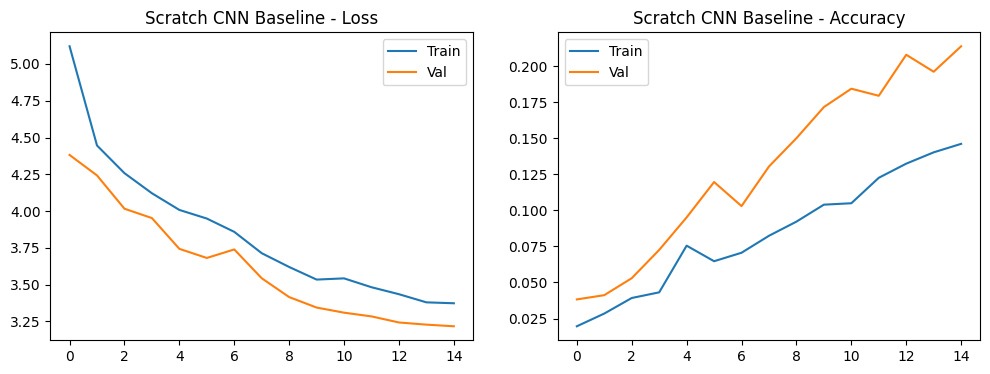

In [18]:
# Optimization settings
criterion = nn.CrossEntropyLoss()
optimizer_scratch = optim.Adam(model_scratch.parameters(), lr=1e-3)
scheduler_scratch = optim.lr_scheduler.CosineAnnealingLR(optimizer_scratch, T_max=15)

# Run training
hist_scratch, best_val_scratch, time_scratch = train_model(
    model_scratch, criterion, optimizer_scratch, scheduler_scratch, num_epochs=15, model_name="Scratch CNN"
)

# Test evaluation
test_acc_scratch = evaluate_model(model_scratch, test_loader)
print(f"Scratch CNN Final Test Accuracy: {test_acc_scratch:.4f}")

# Plot performance curves
plot_history(hist_scratch, "Scratch CNN Baseline")

### Task 2

In [19]:
# Load pretrained ResNet18
model_fe = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)



Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to C:\Users\user/.cache\torch\hub\checkpoints\resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:04<00:00, 10.3MB/s]


In [20]:
# Freeze all backbone layers
for p in model_fe.parameters():
    p.requires_grad = False

In [21]:
# Substitute the classification head for 102 target classes
model_fe.fc = nn.Linear(model_fe.fc.in_features, 102)
model_fe = model_fe.to(device)

In [22]:
# Count and confirm parameter distribution
total_p = sum(p.numel() for p in model_fe.parameters())
trainable_p = sum(p.numel() for p in model_fe.parameters() if p.requires_grad)
print(f"Total Params: {total_p:,} | Trainable Params: {trainable_p:,}")

Total Params: 11,228,838 | Trainable Params: 52,326


In [23]:
# Target only the newly exposed trainable parameters in the optimizer
optimizer_fe = optim.Adam(filter(lambda p: p.requires_grad, model_fe.parameters()), lr=1e-3)

In [24]:
# Run training (15 Epochs)
hist_fe, best_val_fe, time_fe = train_model(
    model_fe, criterion, optimizer_fe, scheduler=None, num_epochs=15, model_name="Feature Extraction"
)


--- Feature Extraction | Epoch 1/15 Training began ---
Batch 32/32 processing... Loss: 4.1713
[Feature Extraction] Epoch 1/15 Result: Train Loss: 4.6581 Acc: 0.0480 | Val Loss: 3.8421 Acc: 0.1951

--- Feature Extraction | Epoch 2/15 Training began ---
Batch 32/32 processing... Loss: 3.1363
[Feature Extraction] Epoch 2/15 Result: Train Loss: 3.3141 Acc: 0.4020 | Val Loss: 2.8973 Acc: 0.5480

--- Feature Extraction | Epoch 3/15 Training began ---
Batch 32/32 processing... Loss: 2.2733
[Feature Extraction] Epoch 3/15 Result: Train Loss: 2.3858 Acc: 0.7118 | Val Loss: 2.2781 Acc: 0.6706

--- Feature Extraction | Epoch 4/15 Training began ---
Batch 32/32 processing... Loss: 1.6255
[Feature Extraction] Epoch 4/15 Result: Train Loss: 1.7636 Acc: 0.8314 | Val Loss: 1.8265 Acc: 0.7412

--- Feature Extraction | Epoch 5/15 Training began ---
Batch 32/32 processing... Loss: 1.3082
[Feature Extraction] Epoch 5/15 Result: Train Loss: 1.3247 Acc: 0.8951 | Val Loss: 1.5322 Acc: 0.7833

--- Feature Ex

In [25]:
# Test evaluation
test_acc_fe = evaluate_model(model_fe, test_loader)
print(f"Feature Extraction Final Test Accuracy: {test_acc_fe:.4f}")

Feature Extraction Final Test Accuracy: 0.8367


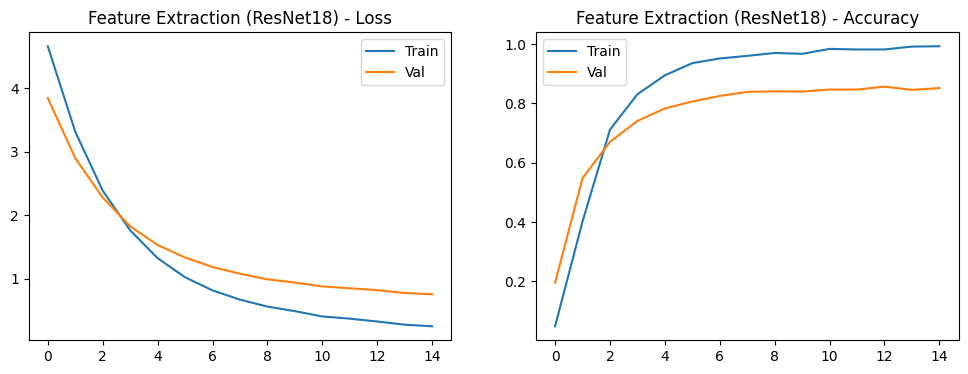

In [26]:
# Plot performance curves
plot_history(hist_fe, "Feature Extraction (ResNet18)")

### Task 3

In [27]:
# Continue training using the weights obtained in Task 2
model_ft = model_fe 

# Unfreeze layer4 and the fc head while keeping the rest frozen
for name, child in model_ft.named_children():
    if name in ['layer4', 'fc']:
        for param in child.parameters():
            param.requires_grad = True
    else:
        for param in child.parameters():
            param.requires_grad = False

In [28]:
# Confirm the new count of trainable parameters
trainable_p_ft = sum(p.numel() for p in model_ft.parameters() if p.requires_grad)
print(f"Trainable Params for Fine-Tuning: {trainable_p_ft:,}")

Trainable Params for Fine-Tuning: 8,446,054


In [29]:
# Setup discriminative learning rates
optimizer_ft = optim.Adam([
    {"params": model_ft.layer4.parameters(), "lr": 1e-5},
    {"params": model_ft.fc.parameters(),    "lr": 1e-3},
])

In [30]:
# Train for an additional 10 epochs
hist_ft, best_val_ft, time_ft = train_model(
    model_ft, criterion, optimizer_ft, scheduler=None, num_epochs=10, model_name="Fine-Tuning"
)


--- Fine-Tuning | Epoch 1/10 Training began ---
Batch 32/32 processing... Loss: 0.2712
[Fine-Tuning] Epoch 1/10 Result: Train Loss: 0.2888 Acc: 0.9794 | Val Loss: 0.7360 Acc: 0.8304

--- Fine-Tuning | Epoch 2/10 Training began ---
Batch 32/32 processing... Loss: 0.2026
[Fine-Tuning] Epoch 2/10 Result: Train Loss: 0.1657 Acc: 0.9922 | Val Loss: 0.6412 Acc: 0.8608

--- Fine-Tuning | Epoch 3/10 Training began ---
Batch 32/32 processing... Loss: 0.0999
[Fine-Tuning] Epoch 3/10 Result: Train Loss: 0.1216 Acc: 0.9971 | Val Loss: 0.5905 Acc: 0.8696

--- Fine-Tuning | Epoch 4/10 Training began ---
Batch 32/32 processing... Loss: 0.0916
[Fine-Tuning] Epoch 4/10 Result: Train Loss: 0.0925 Acc: 0.9971 | Val Loss: 0.5760 Acc: 0.8598

--- Fine-Tuning | Epoch 5/10 Training began ---
Batch 32/32 processing... Loss: 0.1182
[Fine-Tuning] Epoch 5/10 Result: Train Loss: 0.0776 Acc: 0.9980 | Val Loss: 0.5470 Acc: 0.8686

--- Fine-Tuning | Epoch 6/10 Training began ---
Batch 32/32 processing... Loss: 0.09

In [31]:
# Final test evaluation
test_acc_ft = evaluate_model(model_ft, test_loader)
print(f"Fine-Tuning Final Test Accuracy: {test_acc_ft:.4f}")

Fine-Tuning Final Test Accuracy: 0.8614


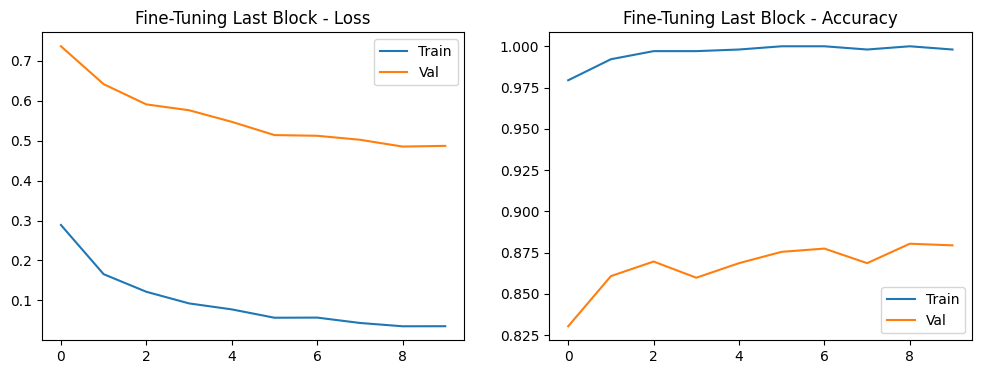

In [32]:
# Plot performance curves
plot_history(hist_ft, "Fine-Tuning Last Block")

In [33]:
import pandas as pd

results = {
    "Approach": ["From scratch (Task 1)", "Feature extraction (Task 2)", "Fine-tune last block (Task 3)"],
    "Trainable params": [f"{total_params:,}", f"{trainable_p:,}", f"{trainable_p_ft:,}"],
    "Best val acc": [f"{best_val_scratch:.4f}", f"{best_val_fe:.4f}", f"{best_val_ft:.4f}"],
    "Test acc": [f"{test_acc_scratch:.4f}", f"{test_acc_fe:.4f}", f"{test_acc_ft:.4f}"],
    "Total training time": [f"{time_scratch:.2f}s", f"{time_fe:.2f}s", f"{time_ft:.2f}s"]
}

df = pd.DataFrame(results)
display(df)

,Approach,Trainable params,Best val acc,Test acc,Total training time
0,From scratch (Task 1),"6,864,742",0.2137,0.1690,1364.75s
1,Feature extraction (Task 2),"52,326",0.8569,0.8367,1230.90s
2,Fine-tune last block (Task 3),"8,446,054",0.8804,0.8614,1031.82s


Applying transfer learning yielded an incredible performance leap compared to training the CNN baseline from scratch, skyrocketing the final test accuracy from a poor 16.90% to over 83%. Because the Oxford Flowers-102 dataset features very few images per class, the scratch-built model aggressively overfit, whereas the pretrained ResNet18 leveraged rich visual features already mastered on ImageNet to generalize immediately. Unfreezing the last residual block (layer4) during fine-tuning provided an additional boost, pushing the test accuracy to its peak at 86.14% by allowing the deepest layers to adapt to unique floral textures and shapes. This configuration provides the absolute best of both worlds: it utilizes the rigid feature maps of early layers to block overfitting on a small dataset while granting the final layers enough flexibility to maximize precise classification metrics.